<a href="https://colab.research.google.com/github/channel1umut-lang/Deep-Learning/blob/main/0010_MultiClassClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DL Datasets/09-iris.csv")

In [ ]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


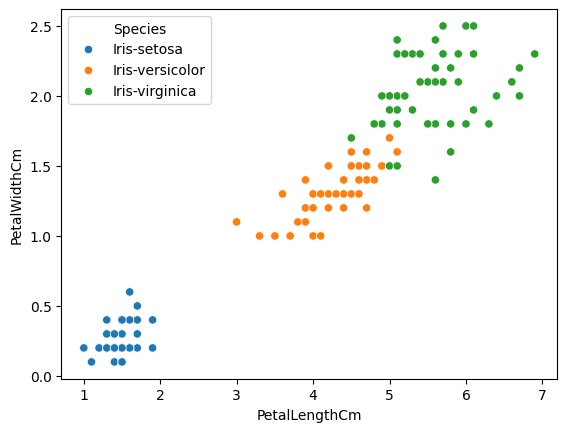

In [ ]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])
plt.show()

In [ ]:
df = df.drop("Id", axis=1)

In [ ]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].values
y = df["Species"].values

In [ ]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [ ]:
# we need to encode y labels
# Encode labels (setosa=0, versicolor=1, virginica=2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # stratify=y demek: Veriyi bölerken sınıf dağılımını koru anlamına gelir.
)

In [ ]:
# in multiclass classification y type should be long because of cross entropy loss function
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape) #Multi de y nin boyutunun bir onemi yok
print(y_test.shape)

torch.Size([120, 4])
torch.Size([30, 4])
torch.Size([120])
torch.Size([30])


In [ ]:
from torch import nn
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(4, 16) # 4 features
        self.layer_2 = nn.Linear(16, 16)
        self.layer_3 = nn.Linear(16, 3)  # 3 classes

        self.relu = nn.ReLU() # btw our model may not even need Relu, it looks like a little bit linear but we can leave it here as well

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [ ]:
# we can also define this class like this, whatever you want
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4, 16),   # input: 4 features
            nn.ReLU(),          # activation

            nn.Linear(16, 16),  # hidden layer
            nn.ReLU(),          # activation

            nn.Linear(16, 3)    # output: 3 classes → logits
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [ ]:
model = IrisClassifier()
model = torch.compile(model)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [ ]:
# prediction probabilities for a multi-class PyTorch model may look like a little bit different

In [ ]:
# Perform a single forward pass on the data without training yet
model(X_test)[:5] # they are Logit

tensor([[0.1690, 0.1399, 0.2282],
        [0.0186, 0.1582, 0.3332],
        [0.1330, 0.1219, 0.2705],
        [0.1386, 0.1181, 0.2663],
        [0.1607, 0.1473, 0.2255]], grad_fn=<SliceBackward0>)

In [ ]:
model(X_test)[0].shape

torch.Size([3])

In [ ]:
# we get 3 values - because we have 3 classes. we get probabilities for each class

In [ ]:
# so we need to get the most probable one and assign the predicted class as that one
# in binary classification we didn't need to do that since we only had 2 class. if it was greater than 0.5 then we assumed it's 1

In [ ]:
y_logits = model(X_test)

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1) #Logitlerden tahmin yapiyo
print(y_logits[:5])
print(y_pred_probs[:5]) # Tahminlerin toplami her zaman 1 cunku softmaxten geliyor.

tensor([[0.1690, 0.1399, 0.2282],
        [0.0186, 0.1582, 0.3332],
        [0.1330, 0.1219, 0.2705],
        [0.1386, 0.1181, 0.2663],
        [0.1607, 0.1473, 0.2255]], grad_fn=<SliceBackward0>)
tensor([[0.3298, 0.3203, 0.3499],
        [0.2841, 0.3267, 0.3892],
        [0.3188, 0.3153, 0.3658],
        [0.3209, 0.3144, 0.3647],
        [0.3275, 0.3231, 0.3494]], grad_fn=<SliceBackward0>)


In [ ]:
# it looks like a very close prediction for each class possibility, because we haven't actually trained the model yet
# but they sum up to 1 (100%)

In [ ]:
torch.sum(y_pred_probs[0])

tensor(1.0000, grad_fn=<SumBackward0>)

In [ ]:
# if i wanted to get the argmax here it would be easy
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0])) # row halinde baktik

tensor([0.3298, 0.3203, 0.3499], grad_fn=<SelectBackward0>)
tensor(2)


In [ ]:
torch.softmax(y_logits, dim=1).argmax(dim = 1)# Softmax in dondurdugu tensorun argmaxi oluyor.

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

In [ ]:
epochs = 200

# let's also try to plot loss - accuracy later on (totally optional)
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    ### TRAIN ###
    model.train()
    logits = model(X_train) #Eğitim verileriyle forward pass yap, ham logit değerlerini hesapla
    loss = loss_fn(logits, y_train) # Logitler ile gerçek etiketler arasındaki kaybı hesapla (CrossEntropyLoss içinde softmax var)

    #pred = torch.argmax(logits, dim=1) (we can get preds like this or the line below. cross entropy loss already containts softmax calculation so it won't change the outcome)
    pred = torch.softmax(logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels...Logitleri önce olasılığa çevir (softmax), sonra en yüksek olasılıklı sınıfın indeksini al (tahmin sınıfı)
    acc = calculate_accuracy(y_train, pred) #Tahmin edilen sınıflar pred ile gerçek etiketler y_train karşılaştırılarak doğruluk oranı hesaplanır.

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item()) # Loss ve accuracy değerlerini listelere ekle (grafik için)
    train_accuracies.append(acc)


    ### TEST ###
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test) #Test verileriyle forward pass yap (sadece tahmin, gradient yok)...Eğitim verileri (X_train) modelden geçirilerek ham logit değerleri elde edilir.
        test_loss = loss_fn(test_logits, y_test) #Test seti için kayıp değerini hesapla # loss_i = - [ y_i * log(σ(z_i)) + (1 - y_i) * log(1 - σ(z_i)) ]
        test_pred = torch.argmax(test_logits, dim=1) #Test logitleri üzerinde doğrudan argmax alınarak tahmin edilen sınıflar bulunur.
        test_acc = calculate_accuracy(y_test, test_pred) #Test tahminlerinin doğruluk oranı hesaplanır.

    test_losses.append(test_loss.item()) # Test loss ve accuracy değerleri listelere eklenir.
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.0622 | Acc: 33.33% | Test Loss: 1.0251 | Test Acc: 33.33%
Epoch 20 | Loss: 0.3103 | Acc: 95.83% | Test Loss: 0.3024 | Test Acc: 96.67%
Epoch 40 | Loss: 0.0766 | Acc: 97.50% | Test Loss: 0.0710 | Test Acc: 100.00%
Epoch 60 | Loss: 0.0561 | Acc: 97.50% | Test Loss: 0.0398 | Test Acc: 100.00%
Epoch 80 | Loss: 0.0517 | Acc: 98.33% | Test Loss: 0.0427 | Test Acc: 100.00%
Epoch 100 | Loss: 0.0497 | Acc: 98.33% | Test Loss: 0.0393 | Test Acc: 100.00%
Epoch 120 | Loss: 0.0476 | Acc: 98.33% | Test Loss: 0.0422 | Test Acc: 100.00%
Epoch 140 | Loss: 0.0461 | Acc: 98.33% | Test Loss: 0.0459 | Test Acc: 100.00%
Epoch 160 | Loss: 0.0449 | Acc: 98.33% | Test Loss: 0.0417 | Test Acc: 100.00%
Epoch 180 | Loss: 0.0441 | Acc: 98.33% | Test Loss: 0.0502 | Test Acc: 96.67%


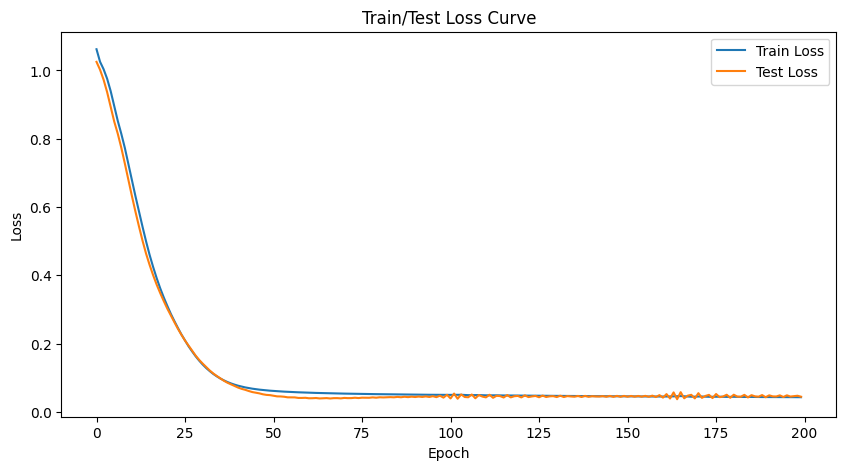

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()
plt.show()

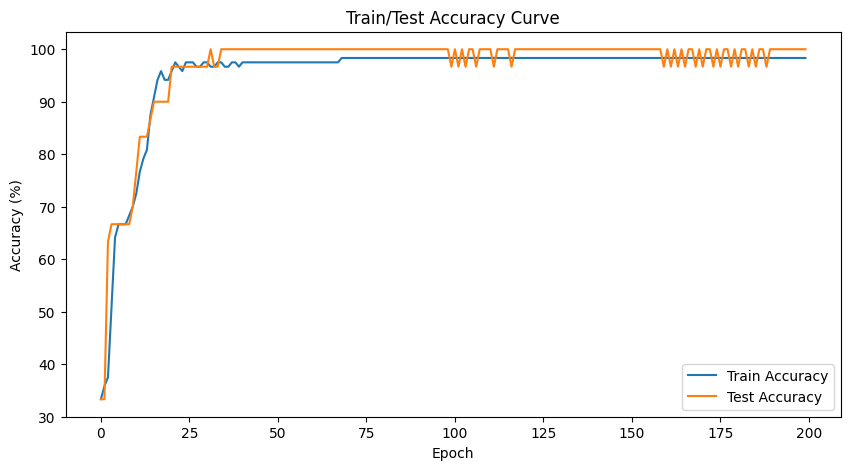

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()
plt.show()

In [ ]:
# let's say we got a new sample flower and try to figure out which class it belongs to

In [ ]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]]) # 4 features in order

In [ ]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32) #yeni bir örnek veriyi (liste, numpy array vb.) PyTorch tensor'una dönüştürür

In [ ]:
model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)#Model, yeni örnek için ham logit değerlerini üretir (sınıflandırma skorları)
    probs = torch.softmax(logits, dim=1) # Logitleri [0,1] aralığında olasılıklara dönüştür (tüm sınıfların toplamı = 1)
    predicted_class = torch.argmax(probs, dim=1).item() #En yüksek olasılığa sahip sınıfın indisini al ve Python scalar'ına çevir

In [ ]:
predicted_label = le.inverse_transform([predicted_class])[0] # decoding gibi sayiyi yaziya cevirdi.

In [ ]:
print("Predicted Class Index:", predicted_class)
print("Predicted Species:", predicted_label)

Predicted Class Index: 0
Predicted Species: Iris-setosa


In [ ]:
# torchmetrics

• Accuracy • Precision • Recall • F1-score • Confusion Matrix • ROC-AUC • Multi-class, multi-label, binary etc. • GPU comptabile

In [ ]:
# we can use torhmetrics for eliminating writing calculate_accuracy functions etc. let's see

In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics.classification import MulticlassAccuracy

In [ ]:
accuracy = MulticlassAccuracy(num_classes=3) # We have to give the class number that we have as a parameter.

#for example we can write
acc = accuracy(preds=pred, target=y_train).item() * 100

#rather than
pred = torch.softmax(logits, dim=1).argmax(dim=1)

acc = calculate_accuracy(y_train, pred)

In [ ]:
# let's do training loop with torchmetrics

In [ ]:
epochs = 200
model2 = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)
for epoch in range(epochs):
    model2.train()
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.argmax(logits, dim=1)
    acc = accuracy(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### TEST ###
    model2.eval()
    with torch.inference_mode():
        test_logits = model2(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.1295 | Acc: 33.33% | Test Loss: 1.0771 | Test Acc: 33.33%
Epoch 20 | Loss: 0.4021 | Acc: 92.50% | Test Loss: 0.3865 | Test Acc: 93.33%
Epoch 40 | Loss: 0.1050 | Acc: 98.33% | Test Loss: 0.1175 | Test Acc: 100.00%
Epoch 60 | Loss: 0.0640 | Acc: 98.33% | Test Loss: 0.0651 | Test Acc: 100.00%
Epoch 80 | Loss: 0.0575 | Acc: 98.33% | Test Loss: 0.0526 | Test Acc: 100.00%
Epoch 100 | Loss: 0.0543 | Acc: 98.33% | Test Loss: 0.0483 | Test Acc: 100.00%
Epoch 120 | Loss: 0.0519 | Acc: 98.33% | Test Loss: 0.0462 | Test Acc: 100.00%
Epoch 140 | Loss: 0.0502 | Acc: 98.33% | Test Loss: 0.0470 | Test Acc: 100.00%
Epoch 160 | Loss: 0.0484 | Acc: 98.33% | Test Loss: 0.0428 | Test Acc: 100.00%
Epoch 180 | Loss: 0.0471 | Acc: 98.33% | Test Loss: 0.0440 | Test Acc: 100.00%


In [ ]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [ ]:
cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)

In [ ]:
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

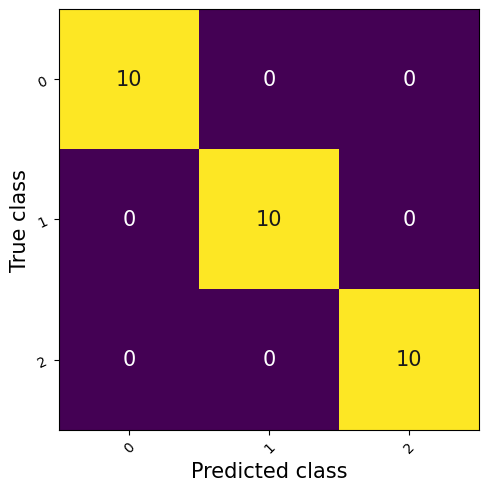

In [ ]:
from torchmetrics.utilities.plot import plot_confusion_matrix
plot_confusion_matrix(matrix)

In [ ]:
#model save - load - deploy

In [ ]:
from pathlib import Path

In [ ]:
MODEL_PATH = Path("models") # Soldaki directory nin icinde model diye bir dosya acti . "models" adında bir yol objesi oluştur.
MODEL_PATH.mkdir(parents=True, exist_ok=True) #.mkdir = Yani bir directory olustur. Parantez icide sunu diyor = Eger daha onceden models klasoru olustuysa bunu olusturma, ancak eger yoksa olustur demek.
MODEL_NAME = "iris_classification_model.pth" #Modelin ismi... .pth onemli deep learning oldugu belli olsun diye.
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME #Tam kayıt yolunu oluştur (models/iris_classification_model.pth). Bolme islemi degil yani :D

torch.save(obj=model2.state_dict(), f=MODEL_SAVE_PATH) #model2.state_dict() ten aldigimiz sonuclari kaydettik.

In [ ]:
model2

IrisClassifier(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [ ]:
model2.state_dict() #state_dict() size hem ağırlık matrislerini (weight) hem de bias vektörlerini (bias) verir. Sadece ağırlıkları değil.

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.4577,  0.4724, -0.4370,  0.3141],
                      [-0.3747,  0.3377, -0.3233,  0.2493],
                      [-0.0668,  0.0709,  0.5435,  1.1082],
                      [-0.2506,  0.1661, -0.4446,  0.1228],
                      [ 0.1743, -0.4705, -0.4407, -0.2560],
                      [ 0.1932,  0.7302, -0.4197, -0.7083],
                      [ 0.6395,  0.6328, -0.3718, -1.0656],
                      [-0.1208,  0.7026, -0.0105, -0.0717],
                      [-0.4149, -0.3824, -0.2943, -0.3579],
                      [ 0.8748,  0.8351,  0.5921, -0.4038],
                      [-0.2932,  0.2219,  0.7490,  0.1881],
                      [-0.4090, -0.4688,  0.0792,  0.3292],
                      [ 0.1603,  0.7540, -0.6098, -0.0997],
                      [ 0.2675,  0.0957,  0.6350,  0.4482],
                      [ 0.0143, -0.1846,  0.7139,  0.8255],
                      [-0.4138,  0.3995,  0.2218, -0.10

In [ ]:
# Model upload and make prediction on it

In [ ]:
loaded_model = IrisClassifier() #Yeni (boş) bir model nesnesi oluştur. (Ağırlıklar rastgele başlatılmıştır; hemen üzerine yüklenecek.)

In [ ]:
type(torch.load(MODEL_SAVE_PATH)) #Kaydedilen dosyanın içindeki verinin tipini göster.

collections.OrderedDict

In [ ]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH)) #Daha önce kaydedilmiş ağırlık sözlüğünü (state_dict) modelin içine yükle.

<All keys matched successfully>

In [ ]:
#Bu kod bloğu, eğitilmiş bir modeli kaydedip yükledikten sonra yeni bir örnek üzerinde tahmin yapmak için yazılmıştır
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]]) #Yeni bir örnek oluştur (4 özellikli).
new_sample_tensor = torch.tensor(new_sample, dtype = torch.float32) #NumPy array’ini PyTorch tensörüne çevir ve veri tipini float32 yap.
loaded_model.eval()
with torch.inference_mode():
    logits = loaded_model(new_sample_tensor) #Tahmin yap – ham logit değerlerini hesapla.
    probs = torch.softmax(logits, dim = 1) #Softmax ile logitleri [0,1] arası olasılıklara çevir.
    predicted_class = torch.argmax(probs, dim=1).item()#En yüksek olasılığa sahip sınıfın indeksini al ve Python sayısına çevir.
le.inverse_transform([predicted_class])[0] #abelEncoder (le) kullanarak sayısal sınıfı orijinal metin etiketine çevir

'Iris-setosa'